In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.DataFrame({
    "iq" : [4,6,7,2],
    "NET_score" : [6,8,5,3]
})

In [4]:
df.head()

,iq,NET_score
0,4,6
1,6,8
2,7,5
3,2,3


In [5]:
X=df['iq']
y = df["NET_score"]

Text(0, 0.5, 'NET score')

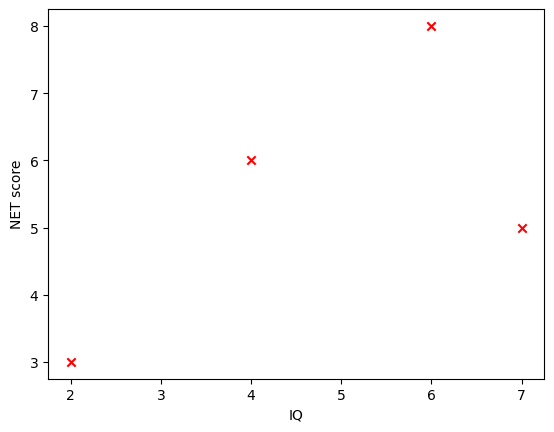

In [6]:
import matplotlib.pyplot as plt
plt.scatter(X, y, marker="x", c='red')
plt.xlabel("IQ")
plt.ylabel("NET score")

### Applying closed form equation

In [7]:
X.values.reshape(4,-1)

array([[4],
       [6],
       [7],
       [2]])

In [8]:
y.values.reshape(4,-1)

array([[6],
       [8],
       [5],
       [3]])

In [9]:
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X.values.reshape(4,-1), y.values.reshape(4,-1))

In [10]:
w = model.coef_[0][0]
b = model.intercept_[0]

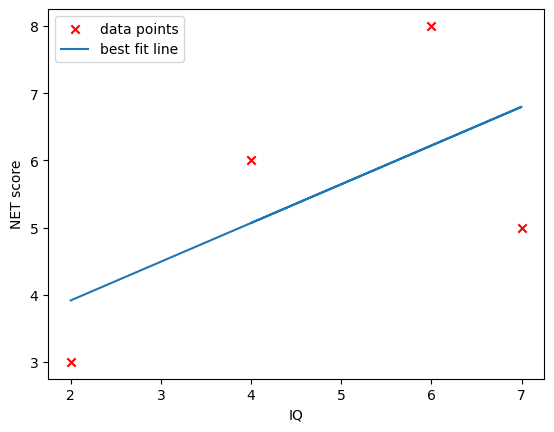

In [11]:
import matplotlib.pyplot as plt
plt.scatter(X, y, marker="x", c='red', label = "data points")
plt.plot(X, w*X+b, label = "best fit line")
plt.xlabel("IQ")
plt.ylabel("NET score")
plt.legend()
plt.show()

In [12]:
print("Weight: ", w)
print("Bias: ", b)

Weight:  0.5762711864406781
Bias:  2.762711864406779


### OLS in multiple linear regression

In [13]:
import pandas as pd
df = pd.DataFrame({
    "iq" : [4,6,7,2],
    "cgpa" : [5,7.6,6.8,4.3],
    "NET_score" : [6,8,5,3]
})

X = df[["iq", "cgpa"]]
y = df['NET_score']

In [14]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression().fit(X,y)

In [28]:
b = lin_reg.intercept_
b

np.float64(-1.8665447897623428)

In [23]:
w = lin_reg.coef_

In [37]:
w

array([-0.40376077,  1.56698877])

In [38]:
import numpy as np

x = np.linspace(df['iq'].min(), df['iq'].max(), 20)
y = np.linspace(df['cgpa'].min(), df['cgpa'].max(), 20)

X_grid, Y_grid = np.meshgrid(x, y)

Z = w[0]*X_grid + w[1]*Y_grid + b

In [39]:
import plotly.graph_objects as go

fig = go.Figure()

# Scatter points
fig.add_trace(go.Scatter3d(
    x=df['iq'],
    y=df['cgpa'],
    z=df['NET_score'],
    mode='markers',
    marker=dict(size=5)
))

# Regression plane
fig.add_trace(go.Surface(
    x=X_grid,
    y=Y_grid,
    z=Z,
    opacity=0.5
))

fig.update_layout(
    scene=dict(
        xaxis_title="IQ",
        yaxis_title="CGPA",
        zaxis_title="NET Score"
    )
)

fig.show()

In [ ]:
import numpy as np
X_new = np.ones((X.shape[0], ))
X_new = np.c_[X_new, X]
B = np.linalg.inv(X_new.T @ X_new) @ X_new.T @ y
bias = B[0]
weights = B[1:]
print("Bias: ", bias)
print("Weights: ", weights)

Bias:  -1.8665447897622975
Weights:  [-0.40376077  1.56698877]


# Gradient Descent

In [44]:
X

,iq,cgpa
0,4,5.0
1,6,7.6
2,7,6.8
3,2,4.3


In [50]:
y = df['NET_score']
y

0    6
1    8
2    5
3    3
Name: NET_score, dtype: int64

In [48]:
from sklearn.linear_model import SGDRegressor
sgd_regressor = SGDRegressor(max_iter=500, alpha=0.01, loss="squared_error").fit(X,y)

In [51]:
sgd_regressor.predict(X)

array([4.64444122, 6.99150675, 6.18425275, 4.0895161 ])

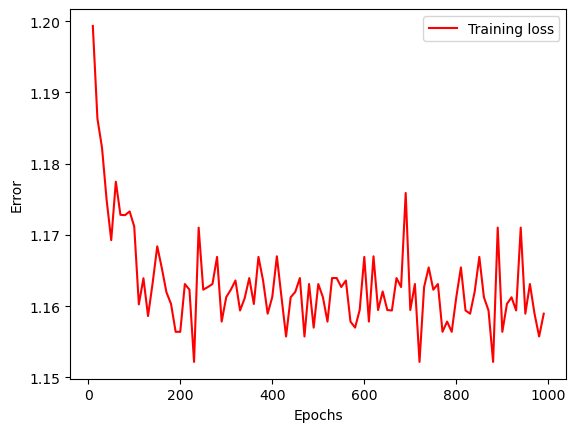

In [62]:
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

error = []
epochs = []

for i in range(10, 1000,10):
    sgd_regressor = SGDRegressor(max_iter=i, alpha=0.01, loss="squared_error").fit(X,y)
    error.append(mean_absolute_error(y, sgd_regressor.predict(X)))
    epochs.append(i)

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.plot(epochs,error,c = 'red', label = "Training loss")
plt.legend()
plt.show()